# 1. Visión por Computadora (CV): La Imagen como Matriz
Una imagen en blanco y negro no es más que una cuadrícula de píxeles. La computadora ve la luz como un número: el 0 es negro absoluto, y el 255 es blanco puro. Vamos a "dibujar" un tensor.

--- EL TRUCO DE LA VISIÓN POR COMPUTADORA ---
1. Así ve el Ingeniero a la imagen (Matriz 2D - Grises):
[[255   0 255]
 [  0 255   0]
 [255   0 255]]

2. Así ve el Ingeniero una imagen a color (Tensor 3D - RGB):
[[[102 220 225]
  [ 95 179  61]
  [234 203  92]]

 [[  3  98 243]
  [ 14 149 245]
  [ 46 106 244]]

 [[ 99 187  71]
  [212 153 199]
  [188 174  65]]]


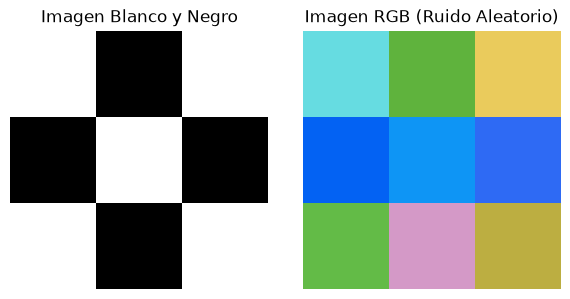


3. Así entra la imagen RGB a la Red Neuronal (Vector 1D):
[102 220 225  95 179  61 234 203  92   3  98 243  14 149 245  46 106 244
  99 187  71 212 153 199 188 174  65]
-> Un solo registro (n=1) con dimensionalidad p=27 (3 píxeles x 3 píxeles x 3 canales).


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("--- EL TRUCO DE LA VISIÓN POR COMPUTADORA ---")

# 1. Imagen en escala de grises de juguete (3x3)
imagen_grises = np.array([
    [255, 0, 255],  # Fila 1
    [0, 255, 0],    # Fila 2
    [255, 0, 255]   # Fila 3
])

print("1. Así ve el Ingeniero a la imagen (Matriz 2D - Grises):")
print(imagen_grises)

# 2. Imagen RGB con ruido aleatorio (Tensor 3D)
# Creamos un tensor de 3x3x3 (Alto x Ancho x 3 Canales RGB) con valores de 0 a 255
np.random.seed(42) # Semilla para que el "ruido" sea siempre el mismo en clase
imagen_rgb = np.random.randint(0, 256, size=(3, 3, 3), dtype=np.uint8)

print("\n2. Así ve el Ingeniero una imagen a color (Tensor 3D - RGB):")
print(imagen_rgb)

# La proyectamos visualmente
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# Mostramos Grises
axes[0].imshow(imagen_grises, cmap='gray')
axes[0].set_title("Imagen Blanco y Negro")
axes[0].axis('off')

# Mostramos RGB
axes[1].imshow(imagen_rgb)
axes[1].set_title("Imagen RGB (Ruido Aleatorio)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Aplanamiento (Flatten) de la imagen RGB para el Machine Learning
vector_rgb = imagen_rgb.flatten()
print("\n3. Así entra la imagen RGB a la Red Neuronal (Vector 1D):")
print(vector_rgb)
print(f"-> Un solo registro (n=1) con dimensionalidad p={len(vector_rgb)} (3 píxeles x 3 píxeles x 3 canales).")

---
# 2. Procesamiento de Lenguaje Natural (NLP): Texto como Geometría
El texto es un problema peor, porque no tiene valores físicos como la luz. La solución fundacional de los años 70 fue el "Bag of Words" (Bolsa de Palabras): contamos frecuencias y usamos el diccionario como si fueran las columnas de nuestra base de datos.

In [ ]:
print("\n--- EL TRUCO DEL LENGUAJE NATURAL ---")
# Tenemos dos documentos (tweets)
doc1 = "el perro corre"
doc2 = "el gato corre"

# Nuestro "Diccionario" es el número de columnas (p)
columnas_nlp = ["el", "perro", "gato", "corre"]

# Contamos cuántas veces aparece cada palabra
matriz_textual = [
    [1, 1, 0, 1], # Vector del doc1
    [1, 0, 1, 1]  # Vector del doc2
]

df_nlp = pd.DataFrame(matriz_textual, columns=columnas_nlp, index=["Doc1", "Doc2"])

print("Matriz X para los textos:")
display(df_nlp)
print("¡El texto ahora es geometría! Podemos calcular la distancia euclidiana entre el Doc1 y el Doc2.")

---
# 3. La Maldición de la Dimensionalidad (The Curse of Dimensionality)
En nuestra matriz de juguete NLP, $p=4$. En la imagen, $p=9$. 
Pero, ¿qué pasa si entrenamos con una foto de 1080p? Tendremos $p = 2,000,000$. En espacios matemáticos masivos, la distancia entre un punto y sus vecinos colapsa; todo parece estar a la misma distancia de todo, y el algoritmo se vuelve ciego.